# Eksperimen MSML - Telco Customer Churn
**Nama:** Amira
**Proyek:** Membangun Sistem Machine Learning - Dicoding Indonesia

## 1. Perkenalan Dataset

Dataset yang digunakan pada eksperimen ini adalah **Telco Customer Churn**, dataset publik yang berisi data
pelanggan sebuah perusahaan telekomunikasi beserta informasi apakah pelanggan tersebut berhenti berlangganan
(*churn*) atau tidak.

- **Sumber**: Dataset publik (format CSV), tersedia di repository raw dataset (lihat `namadataset_raw/`).
- **Jumlah baris**: 7.043 pelanggan
- **Jumlah kolom**: 21 kolom (20 fitur + 1 target)
- **Target**: `Churn` (Yes/No) — apakah pelanggan berhenti berlangganan
- **Tipe masalah**: Klasifikasi biner (binary classification)

Dataset ini cocok untuk pipeline MLOps end-to-end karena mengandung data kategorikal, data numerik,
beberapa nilai yang perlu dibersihkan (missing/blank values), serta target yang tidak seimbang (imbalanced),
sehingga banyak tahapan preprocessing yang relevan untuk didemonstrasikan.

## 2. Import Library

Pada tahap ini kita mengimpor seluruh pustaka yang dibutuhkan untuk EDA, preprocessing, dan visualisasi.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")


## 3. Memuat Dataset

Dataset disimpan dalam format CSV pada folder `namadataset_raw/telco_customer_churn_raw.csv`.
Kita muat dataset tersebut menggunakan `pandas`, lalu memeriksa beberapa baris awal untuk memastikan
data sudah termuat dengan benar.

In [29]:
df = pd.read_csv("../namadataset_raw/telco_customer_churn_raw.csv")

print("Ukuran dataset:", df.shape)
df.head()


Ukuran dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [30]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 4. Exploratory Data Analysis (EDA)

Pada tahap ini kita akan menggali karakteristik dataset: distribusi target, missing values, duplikasi,
distribusi fitur numerik, serta hubungan antar fitur terhadap target `Churn`.

In [31]:
# Cek missing value per kolom
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [32]:
# Cek duplikasi baris
print("Jumlah baris duplikat:", df.duplicated().sum())

# Statistik deskriptif untuk fitur numerik
df.describe()


Jumlah baris duplikat: 0


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


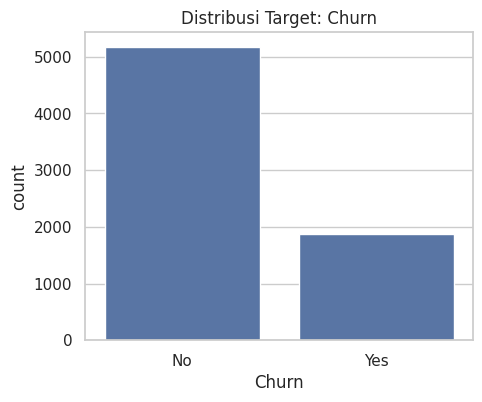

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [33]:
# Distribusi target (Churn)
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Churn")
plt.title("Distribusi Target: Churn")
plt.show()

print(df["Churn"].value_counts(normalize=True))


In [34]:
# TotalCharges seharusnya numerik, tapi terbaca sebagai object -> cek penyebabnya
non_numeric = df[pd.to_numeric(df["TotalCharges"], errors="coerce").isnull()]
print("Baris dengan TotalCharges tidak valid (blank/spasi):", non_numeric.shape[0])
non_numeric[["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]


Baris dengan TotalCharges tidak valid (blank/spasi): 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


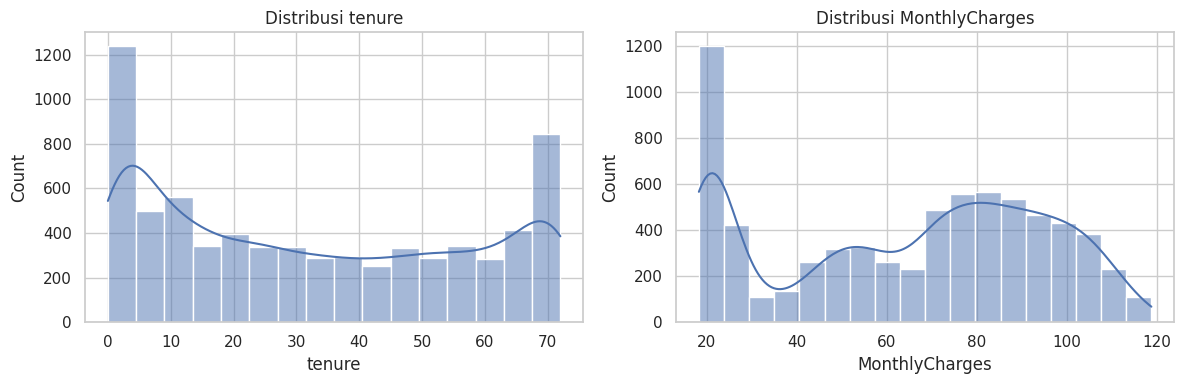

In [35]:
# Distribusi fitur numerik
num_cols = ["tenure", "MonthlyCharges"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribusi {col}")
plt.tight_layout()
plt.show()


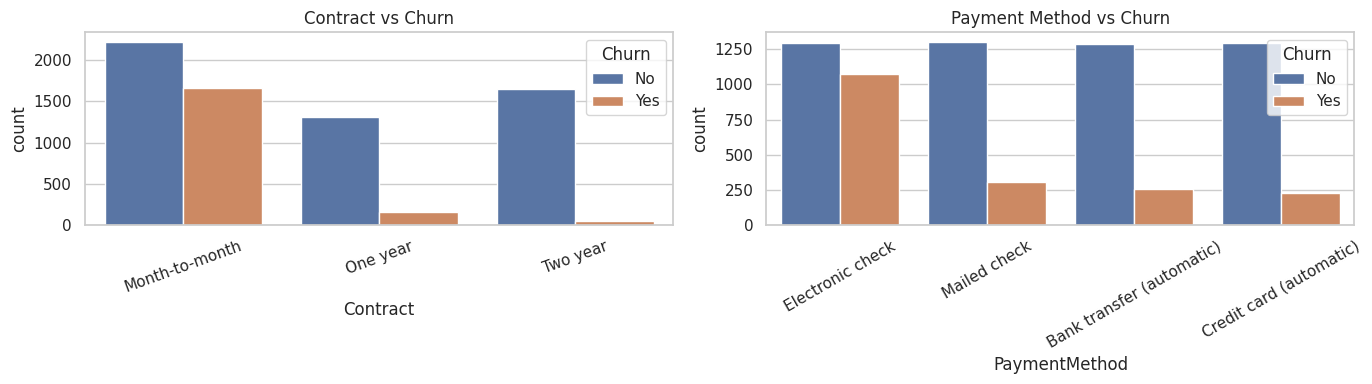

In [36]:
# Hubungan Contract & PaymentMethod terhadap Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[0])
axes[0].set_title("Contract vs Churn")
axes[0].tick_params(axis='x', rotation=20)

sns.countplot(data=df, x="PaymentMethod", hue="Churn", ax=axes[1])
axes[1].set_title("Payment Method vs Churn")
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


**Insight EDA singkat:**
- Target `Churn` bersifat *imbalanced* (± 73% No, 27% Yes), perlu diperhatikan saat evaluasi model (gunakan precision/recall/F1, bukan hanya accuracy).
- Kolom `TotalCharges` terbaca sebagai teks karena terdapat baris dengan nilai kosong (spasi) — perlu dikonversi ke numerik dan ditangani pada tahap preprocessing.
- Pelanggan dengan kontrak `Month-to-month` cenderung memiliki churn rate lebih tinggi dibanding kontrak jangka panjang.
- Tidak ditemukan baris yang sepenuhnya duplikat pada data mentah.

## 5. Data Preprocessing

Berdasarkan hasil EDA, berikut tahapan preprocessing yang dilakukan:
1. Menghapus kolom `customerID` (bersifat unik, tidak informatif untuk model).
2. Menangani nilai kosong pada `TotalCharges` (konversi ke numerik, isi dengan median).
3. Menghapus data duplikat (jika ditemukan setelah `customerID` dihapus).
4. Encoding fitur kategorikal menggunakan `LabelEncoder`.
5. Encoding target `Churn` menjadi biner (0/1).
6. Standarisasi fitur numerik (`tenure`, `MonthlyCharges`, `TotalCharges`) menggunakan `StandardScaler`.

In [37]:
df_clean = df.copy()

# 1. Hapus kolom yang tidak informatif
df_clean = df_clean.drop(columns=["customerID"])

# 2. Tangani TotalCharges (blank -> NaN -> isi median)
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(df_clean["TotalCharges"].median())

# 3. Hapus duplikat
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
print(f"Baris duplikat dihapus: {before - df_clean.shape[0]}")


Baris duplikat dihapus: 22


In [38]:
# 4 & 5. Encoding kategorikal + target
cat_cols = df_clean.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols if c != "Churn"]

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    encoders[col] = le

df_clean["Churn"] = df_clean["Churn"].map({"No": 0, "Yes": 1})


In [39]:
# 6. Standarisasi fitur numerik
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

df_clean.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,-1.282728,0,1,0,0,2,0,0,0,0,0,1,2,-1.164135,-0.997328,0
1,1,0,0,0,0.062387,1,0,0,2,0,2,0,0,0,1,0,3,-0.262811,-0.176347,0
2,1,0,0,0,-1.241967,1,0,0,2,2,0,0,0,0,0,1,3,-0.365914,-0.962760,1
3,1,0,0,0,0.510759,0,1,0,2,0,2,2,0,0,1,0,0,-0.750058,-0.197869,0
4,0,0,0,0,-1.241967,1,0,1,0,0,0,0,0,0,0,1,2,0.194503,-0.943556,1


In [40]:
print("Ukuran data setelah preprocessing:", df_clean.shape)
df_clean.isnull().sum().sum()  # pastikan tidak ada missing value tersisa


Ukuran data setelah preprocessing: (7021, 20)


np.int64(0)

## 6. Menyimpan Dataset Hasil Preprocessing

Dataset yang sudah bersih disimpan ke folder `namadataset_preprocessing/` agar dapat digunakan langsung
pada tahap **Membangun Model** (Kriteria 2) tanpa perlu mengulang proses cleaning.

In [41]:
import os
os.makedirs("namadataset_preprocessing", exist_ok=True)
df_clean.to_csv("namadataset_preprocessing/telco_customer_churn_preprocessing.csv", index=False)
print("Dataset hasil preprocessing berhasil disimpan.")


Dataset hasil preprocessing berhasil disimpan.


In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
import os
os.chdir('/content/drive/MyDrive/Eksperimen_SML_Amira/preprocessing')
print(os.getcwd())
print(os.listdir())

/content/drive/MyDrive/Eksperimen_SML_Amira/preprocessing
['Eksperimen_Amira.ipynb', 'namadataset_preprocessing']
